# Генерация датасета для моделирования пробоя диэлектрика

Планирование параметров, запуск симуляций и сохранение результатов для обучения ML-моделей.

In [1]:
from pathlib import Path
import sys

import numpy as np
import pandas as pd
from scipy.stats import qmc

PROJECT_ROOT = Path.cwd()

if not (PROJECT_ROOT / "src").is_dir():
    PROJECT_ROOT = PROJECT_ROOT.parent

assert (PROJECT_ROOT / "src").is_dir(), "Не найдена папка src"

sys.path.insert(0, str(PROJECT_ROOT))

from src.config import SimulationConfig
from src.simulator import run_simulation

print("Корень проекта:", PROJECT_ROOT)

Корень проекта: /home/artur/PycharmProjects/Mathprac


In [2]:
OUT = PROJECT_ROOT / "data" / "ml_dataset"
OUT.mkdir(parents=True, exist_ok=True)

MASTER_SEED = 20260924

PARAMETERS = (
    "eta",
    "mean_breakdown_field",
    "correlation_length",
    "weibull_shape",
)

BOUNDS = np.array([
    [0.5, 3.0],
    [2.7, 3.3],
    [1.0, 15.0],
    [2.0, 15.0],
])

for name, (low, high) in zip(PARAMETERS, BOUNDS):
    print(f"{name}: от {low:g} до {high:g}")

eta: от 0.5 до 3
mean_breakdown_field: от 2.7 до 3.3
correlation_length: от 1 до 15
weibull_shape: от 2 до 15


In [6]:
def sobol_points(power, seed):
    sampler = qmc.Sobol(
        d = len(PARAMETERS),
        scramble=True,
        seed = seed
    )

    return sampler.random_base2(m=power)

def to_physical(unit_points):
    values = qmc.scale(
        unit_points,
        BOUNDS[:, 0],
        BOUNDS[:, 1],
    )

    values[:, 2] = 1 + np.floor(
        15 * unit_points[:, 2]
    )

    return values


unit_demo = sobol_points(power=3, seed=MASTER_SEED)
physical_demo = to_physical(unit_demo)
physical_demo = pd.DataFrame(
    to_physical(unit_demo),
    columns=PARAMETERS,
)
physical_demo["correlation_length"] = (
    physical_demo["correlation_length"].astype(int)
)

display(physical_demo)

,eta,mean_breakdown_field,correlation_length,weibull_shape
0,1.040262,3.126133,11,3.960698
1,2.360888,2.788223,6,9.935991
2,2.524562,3.184346,13,5.699127
3,1.188938,2.922237,2,14.289726
4,1.561072,3.285038,6,12.044601
5,2.741055,2.948226,9,8.453652
6,1.951620,3.006847,3,10.710835
7,0.787852,2.743639,14,2.879581


In [7]:
PHASE_CODE = {
    "global": 0,
    "repeat": 1,
    "test": 2,
    "adaptive": 3,
}


def make_seed(phase, point, material, growth, kind):
    sequence = np.random.SeedSequence([
        MASTER_SEED,
        PHASE_CODE[phase],
        point,
        material,
        growth,
        kind,
    ])

    return int(
        sequence.generate_state(
            1,
            dtype=np.uint64,
        )[0]
    )


disorder_0 = make_seed("repeat", 0, 0, 0, kind=0)
disorder_1 = make_seed("repeat", 0, 0, 0, kind=0)

growth_0 = make_seed("repeat", 0, 0, 0, kind=1)
growth_1 = make_seed("repeat", 0, 0, 1, kind=1)

print("Одна карта:", disorder_0 == disorder_1)
print("Разные траектории:", growth_0 != growth_1)

Одна карта: True
Разные траектории: True


In [8]:
def make_run(phase, split, point, material, growth, theta):
    return {
        "run_id": f"{phase}-{point:06d}-m{material}-g{growth}",
        "point_id": f"{phase}-{point:06d}",
        "phase": phase,
        "split": split,
        "material_rep": material,
        "growth_rep": growth,
        "eta": float(theta[0]),
        "mean_breakdown_field": float(theta[1]),
        "correlation_length": int(theta[2]),
        "weibull_shape": float(theta[3]),
        "disorder_seed": make_seed(
            phase, point, material, 0, kind=0
        ),
        "random_seed": make_seed(
            phase, point, material, growth, kind=1
        ),
    }


theta_example = to_physical(
    sobol_points(power=1, seed=MASTER_SEED)
)[0]

first = make_run("repeat", "train", 0, 0, 0, theta_example)
second = make_run("repeat", "train", 0, 0, 1, theta_example)

display(pd.DataFrame([first, second]))

,run_id,point_id,phase,split,material_rep,growth_rep,eta,mean_breakdown_field,correlation_length,weibull_shape,disorder_seed,random_seed
0,repeat-000000-m0-g0,repeat-000000,repeat,train,0,0,1.040262,3.126133,11,3.960698,10561391026471685512,2908680812909465138
1,repeat-000000-m0-g1,repeat-000000,repeat,train,0,1,1.040262,3.126133,11,3.960698,10561391026471685512,14161297878975501555


In [9]:
def make_runs(unit_points, phase, split, n_materials, n_growth):
    physical_points = to_physical(unit_points)
    rows = []

    for point, theta in enumerate(physical_points):
        for material in range(n_materials):
            for growth in range(n_growth):
                row = make_run(
                    phase, split, point, material, growth, theta
                )
                rows.append(row)

    return pd.DataFrame(rows)


demo_plan = make_runs(
    unit_points=sobol_points(power=1, seed=MASTER_SEED),
    phase="repeat",
    split="train",
    n_materials=2,
    n_growth=2,
)

display(demo_plan)
print("Всего запусков:", len(demo_plan))

,run_id,point_id,phase,split,material_rep,growth_rep,eta,mean_breakdown_field,correlation_length,weibull_shape,disorder_seed,random_seed
0,repeat-000000-m0-g0,repeat-000000,repeat,train,0,0,1.040262,3.126133,11,3.960698,10561391026471685512,2908680812909465138
1,repeat-000000-m0-g1,repeat-000000,repeat,train,0,1,1.040262,3.126133,11,3.960698,10561391026471685512,14161297878975501555
2,repeat-000000-m1-g0,repeat-000000,repeat,train,1,0,1.040262,3.126133,11,3.960698,6614432053288046201,17849364914730290319
3,repeat-000000-m1-g1,repeat-000000,repeat,train,1,1,1.040262,3.126133,11,3.960698,6614432053288046201,15558296200675201125
4,repeat-000001-m0-g0,repeat-000001,repeat,train,0,0,2.360888,2.788223,6,9.935991,16346129398486368875,13669344353490794631
5,repeat-000001-m0-g1,repeat-000001,repeat,train,0,1,2.360888,2.788223,6,9.935991,16346129398486368875,10473701627491661051
6,repeat-000001-m1-g0,repeat-000001,repeat,train,1,0,2.360888,2.788223,6,9.935991,512444173220061123,13856238784106891358
7,repeat-000001-m1-g1,repeat-000001,repeat,train,1,1,2.360888,2.788223,6,9.935991,512444173220061123,7158622047565248628


Всего запусков: 8


In [10]:
PLAN_FILE = OUT / "plan_initial.csv"

if PLAN_FILE.exists():
    plan = pd.read_csv(
        PLAN_FILE,
        dtype={
            "disorder_seed": "uint64",
            "random_seed": "uint64",
        },
    )
else:
    global_runs = make_runs(
        sobol_points(power=13, seed=MASTER_SEED),
        phase="global",
        split="train",
        n_materials=1,
        n_growth=1,
    )

    repeated_runs = make_runs(
        sobol_points(power=9, seed=MASTER_SEED + 1),
        phase="repeat",
        split="train",
        n_materials=4,
        n_growth=2,
    )

    test_runs = make_runs(
        sobol_points(power=11, seed=MASTER_SEED + 2),
        phase="test",
        split="test",
        n_materials=2,
        n_growth=1,
    )

    plan = pd.concat(
        [global_runs, repeated_runs, test_runs],
        ignore_index=True,
    )

    assert plan["run_id"].is_unique
    plan.to_csv(PLAN_FILE, index=False)

display(plan.groupby(["split", "phase"]).size())
print("Всего запланировано:", len(plan))
print("Файл плана:", PLAN_FILE)

split  phase 
test   test      4096
train  global    8192
       repeat    4096
dtype: int64

Всего запланировано: 16384
Файл плана: /home/artur/PycharmProjects/Mathprac/data/ml_dataset/plan_initial.csv


In [11]:
from dataclasses import replace
from time import perf_counter

row = plan.loc[
    plan["phase"] == "global"
].head(1).to_dict("records")[0]

base_config = SimulationConfig(
    nx=128,
    ny=128,
    max_growth_steps=5000,
)

config = replace(
    base_config,
    eta=float(row["eta"]),
    mean_breakdown_field=float(row["mean_breakdown_field"]),
    correlation_length=int(row["correlation_length"]),
    weibull_shape=float(row["weibull_shape"]),
    disorder_seed=int(row["disorder_seed"]),
    random_seed=int(row["random_seed"]),
)

start = perf_counter()
field, history, breakdown = run_simulation(config)
elapsed = perf_counter() - start

print("run_id:", row["run_id"])
print("Шагов роста:", len(history))
print("Площадь канала:", int(field.channel.sum()))
print("Полный пробой:", breakdown)
print(f"Время: {elapsed:.2f} с")

run_id: global-000000-m0-g0
Шагов роста: 0
Площадь канала: 0
Полный пробой: False
Время: 0.21 с


In [13]:
def simulate_row(row):
    cfg = replace(
        base_config,
        eta=float(row["eta"]),
        mean_breakdown_field=float(row["mean_breakdown_field"]),
        correlation_length=int(row["correlation_length"]),
        weibull_shape=float(row["weibull_shape"]),
        disorder_seed=int(row["disorder_seed"]),
        random_seed=int(row["random_seed"]),
    )

    start = perf_counter()
    field, history, breakdown = run_simulation(cfg)
    elapsed = perf_counter() - start

    if breakdown:
        status = "breakdown"
    elif len(history) == 0:
        status = "no_start"
    elif len(history) >= cfg.max_growth_steps:
        status = "max_steps"
    else:
        status = "arrested"

    return {
        "run_id": row["run_id"],
        "status": status,
        "steps": len(history),
        "area": int(field.channel.sum()),
        "time_seconds": elapsed,
    }

In [15]:
BACKUP_FILE = OUT / "plan_initial_before_lc_adjustment.csv"

if not BACKUP_FILE.exists():
    plan.to_csv(BACKUP_FILE, index=False)

low_lc_points = sobol_points(
    power=8,
    seed=MASTER_SEED + 11,
)
low_lc_points[:, 2] /= 3

wide_points = sobol_points(
    power=8,
    seed=MASTER_SEED + 12,
)

repeat_points = np.vstack([
    low_lc_points,
    wide_points,
])

new_repeated_runs = make_runs(
    repeat_points,
    phase="repeat",
    split="train",
    n_materials=4,
    n_growth=2,
)

plan = pd.concat([
    plan.loc[plan["phase"] == "global"],
    new_repeated_runs,
    plan.loc[plan["phase"] == "test"],
], ignore_index=True)

assert plan["run_id"].is_unique
assert len(plan) == 16384

plan.to_csv(PLAN_FILE, index=False)

display(
    pd.crosstab(
        plan["phase"],
        plan["correlation_length"] <= 5,
    ).rename(columns={
        False: "l_c > 5",
        True: "l_c ≤ 5",
    })
)

correlation_length,l_c > 5,l_c ≤ 5
phase,,
global,5461,2731
repeat,1368,2728
test,2730,1366


In [16]:
IMAGES_DIR = OUT / "images"
IMAGES_DIR.mkdir(parents=True, exist_ok=True)


def simulate_and_save(row):
    cfg = replace(
        base_config,
        eta=float(row["eta"]),
        mean_breakdown_field=float(row["mean_breakdown_field"]),
        correlation_length=int(row["correlation_length"]),
        weibull_shape=float(row["weibull_shape"]),
        disorder_seed=int(row["disorder_seed"]),
        random_seed=int(row["random_seed"]),
    )

    start = perf_counter()
    field, history, breakdown = run_simulation(cfg)
    elapsed = perf_counter() - start

    if breakdown:
        status = "breakdown"
    elif len(history) == 0:
        status = "no_start"
    elif len(history) >= cfg.max_growth_steps:
        status = "max_steps"
    else:
        status = "arrested"

    channel = field.channel
    occupied_y = np.flatnonzero(channel.any(axis=1))

    image_path = ""
    if occupied_y.size > 0:
        image_path = f'images/{row["run_id"]}.npz'
        np.savez_compressed(
            OUT / image_path,
            channel=channel.astype(np.uint8),
        )

    return {
        "run_id": row["run_id"],
        "status": status,
        "steps": len(history),
        "area": int(channel.sum()),
        "height_fraction": (
            float(occupied_y[-1] / (cfg.ny - 1))
            if occupied_y.size > 0 else 0.0
        ),
        "time_seconds": elapsed,
        "image_path": image_path,
    }

{'run_id': 'global-000003-m0-g0', 'status': 'breakdown', 'steps': 349, 'area': 349, 'height_fraction': 1.0, 'time_seconds': 2.872607496996352, 'image_path': 'images/global-000003-m0-g0.npz'}


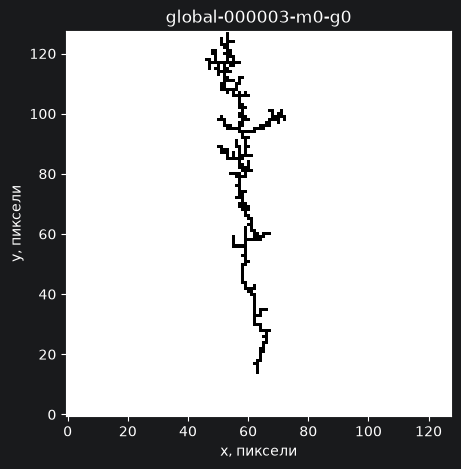

In [17]:
import matplotlib.pyplot as plt

example_id = pilot_results.loc[
    pilot_results["status"] == "breakdown",
    "run_id",
].iloc[0]

example_row = plan.loc[
    plan["run_id"] == example_id
].to_dict("records")[0]

record = simulate_and_save(example_row)

with np.load(OUT / record["image_path"]) as saved:
    mask = saved["channel"]

assert mask.shape == (128, 128)
assert int(mask.sum()) == record["area"]

previous_steps = pilot_results.loc[
    pilot_results["run_id"] == example_id,
    "steps",
].iloc[0]

assert record["steps"] == previous_steps

print(record)

plt.figure(figsize=(5, 5))
plt.imshow(mask, cmap="gray_r", origin="lower")
plt.title(example_id)
plt.xlabel("x, пиксели")
plt.ylabel("y, пиксели")
plt.show()

In [18]:
import json
from dataclasses import asdict
from joblib import Parallel, delayed, parallel_config

RESULTS_FILE = OUT / "results.jsonl"
CONFIG_FILE = OUT / "simulation_config.json"

current_config = json.loads(
    json.dumps(asdict(base_config))
)

if CONFIG_FILE.exists():
    saved_config = json.loads(
        CONFIG_FILE.read_text(encoding="utf-8")
    )
    if saved_config != current_config:
        raise ValueError("Настройки симуляции изменились")
elif RESULTS_FILE.exists():
    raise ValueError("У существующих результатов нет настроек")
else:
    CONFIG_FILE.write_text(
        json.dumps(current_config, indent=2),
        encoding="utf-8",
    )


def run_many(part, n_jobs=4, batch_size=16):
    if not part["run_id"].is_unique:
        raise ValueError("В переданном плане есть повторные run_id")

    completed = set()

    if RESULTS_FILE.exists():
        with RESULTS_FILE.open(encoding="utf-8") as file:
            completed = {
                json.loads(line)["run_id"]
                for line in file
                if line.strip()
            }

    remaining = part.loc[
        ~part["run_id"].isin(completed)
    ]

    print("Осталось запусков:", len(remaining))

    for start in tqdm(
        range(0, len(remaining), batch_size)
    ):
        batch = remaining.iloc[
            start:start + batch_size
        ].to_dict("records")

        with parallel_config(
            backend="loky",
            inner_max_num_threads=1,
        ):
            records = Parallel(n_jobs=n_jobs)(
                delayed(simulate_and_save)(row)
                for row in batch
            )

        with RESULTS_FILE.open("a", encoding="utf-8") as file:
            for record in records:
                file.write(
                    json.dumps(record, ensure_ascii=False) + "\n"
                )
            file.flush()

In [19]:
import json
from dataclasses import asdict
from joblib import Parallel, delayed, parallel_config

RESULTS_FILE = OUT / "results.jsonl"
CONFIG_FILE = OUT / "simulation_config.json"

current_config = json.loads(
    json.dumps(asdict(base_config))
)

if CONFIG_FILE.exists():
    saved_config = json.loads(
        CONFIG_FILE.read_text(encoding="utf-8")
    )
    if saved_config != current_config:
        raise ValueError("Настройки симуляции изменились")
elif RESULTS_FILE.exists():
    raise ValueError("У существующих результатов нет настроек")
else:
    CONFIG_FILE.write_text(
        json.dumps(current_config, indent=2),
        encoding="utf-8",
    )


def run_many(part, n_jobs=4, batch_size=16):
    if not part["run_id"].is_unique:
        raise ValueError("В переданном плане есть повторные run_id")

    completed = set()

    if RESULTS_FILE.exists():
        with RESULTS_FILE.open(encoding="utf-8") as file:
            completed = {
                json.loads(line)["run_id"]
                for line in file
                if line.strip()
            }

    remaining = part.loc[
        ~part["run_id"].isin(completed)
    ]

    print("Осталось запусков:", len(remaining))

    for start in tqdm(
        range(0, len(remaining), batch_size)
    ):
        batch = remaining.iloc[
            start:start + batch_size
        ].to_dict("records")

        with parallel_config(
            backend="loky",
            inner_max_num_threads=1,
        ):
            records = Parallel(n_jobs=n_jobs)(
                delayed(simulate_and_save)(row)
                for row in batch
            )

        with RESULTS_FILE.open("a", encoding="utf-8") as file:
            for record in records:
                file.write(
                    json.dumps(record, ensure_ascii=False) + "\n"
                )
            file.flush()

In [20]:
smoke_part = plan.loc[
    plan["phase"] == "global"
].head(4)

run_many(
    smoke_part,
    n_jobs=2,
    batch_size=2,
)

# Повторный вызов должен вывести: «Осталось запусков: 0».
run_many(
    smoke_part,
    n_jobs=2,
    batch_size=2,
)

saved_results = pd.read_json(
    RESULTS_FILE,
    lines=True,
)

smoke_results = saved_results.loc[
    saved_results["run_id"].isin(smoke_part["run_id"])
]

assert len(smoke_results) == 4
assert smoke_results["run_id"].is_unique

for image_path in smoke_results["image_path"].fillna(""):
    if image_path:
        assert (OUT / image_path).exists()

display(smoke_results)

Осталось запусков: 4


  0%|          | 0/2 [00:00<?, ?it/s]

Осталось запусков: 0


0it [00:00, ?it/s]

,run_id,status,steps,area,height_fraction,time_seconds,image_path
0,global-000000-m0-g0,no_start,0,0,0,0.201611,
1,global-000001-m0-g0,no_start,0,0,0,0.201284,
2,global-000002-m0-g0,no_start,0,0,0,0.029518,
3,global-000003-m0-g0,breakdown,349,349,1,2.861374,images/global-000003-m0-g0.npz


# Генерация датасета для модели пробоя диэлектрика

В этом ноутбуке мы запускаем модель роста электрического канала и сохраняем результаты для последующего обучения ML-моделей.

Меняем четыре параметра модели:

- `eta` — насколько сильно электрическое поле влияет на направление роста;
- `mean_breakdown_field` — средний порог пробоя материала;
- `correlation_length` — размер связанных областей в случайной карте материала;
- `weibull_shape` — параметр распределения локальной прочности материала.

## Части датасета

| Часть | Запусков | Цель |
|---|---:|---|
| `global` | 8 192 | Охватить весь выбранный диапазон параметров и собрать основную обучающую выборку. |
| `repeat` | 4 096 | Повторить одни и те же параметры с разными случайными картами материала и траекториями роста. Это поможет оценить случайный разброс. Малые значения `correlation_length` встречаются здесь чаще. |
| `adaptive` | 4 096 | Добавить запуски в областях, где исход особенно чувствителен к параметрам. Точки выберем после анализа `global` и `repeat`. |
| `test` | 4 096 | Проверить обученные модели на новых комбинациях параметров. Этот набор не используем при обучении и выборе точек `adaptive`. |

**Всего запланировано: 20 480 запусков.** Сейчас выполняются `global` и `repeat` — 12 288 запусков.

## Как используем результаты

1. По параметрам будем предсказывать, стартует ли канал и произойдёт ли полный пробой.
2. По изображениям выросших каналов будем пробовать восстановить параметры, которые привели к такой форме.
3. Качество моделей в конце оценим на отложенной части `test`.

In [21]:
initial_train = plan.loc[
    plan["phase"].isin(["global", "repeat"])
].copy()

assert len(initial_train) == 12288
assert (initial_train["split"] == "train").all()

run_many(
    initial_train,
    n_jobs=4,
    batch_size=16,
)

Осталось запусков: 12284


  0%|          | 0/768 [00:00<?, ?it/s]

In [22]:
results = pd.read_json(RESULTS_FILE, lines=True)

assert results["run_id"].is_unique, "В файле есть повторяющиеся run_id"

train_results = initial_train[
    ["run_id", "point_id", "phase"]
].merge(
    results,
    on="run_id",
    how="left",
    validate="one_to_one",
)

assert len(train_results) == 12288
assert train_results["status"].notna().all(), "Не все запуски завершились"

image_paths = train_results["image_path"].fillna("")
missing_images = [
    path for path in image_paths
    if path and not (OUT / path).is_file()
]
assert not missing_images, f"Не найдены изображения: {missing_images[:5]}"

display(pd.crosstab(
    train_results["phase"],
    train_results["status"],
    margins=True,
))

display(pd.crosstab(
    train_results["phase"],
    train_results["status"],
    normalize="index",
).round(3))

status,arrested,breakdown,no_start,All
phase,,,,
global,212,3669,4311,8192
repeat,184,1884,2028,4096
All,396,5553,6339,12288


status,arrested,breakdown,no_start
phase,,,
global,0.026,0.448,0.526
repeat,0.045,0.460,0.495


In [23]:
=global_lc = initial_train.loc[
    initial_train["phase"] == "global",
    ["run_id", "correlation_length"],
].merge(
    train_results[["run_id", "status"]],
    on="run_id",
    validate="one_to_one",
)

global_lc["started"] = global_lc["status"] != "no_start"
global_lc["arrested"] = global_lc["status"] == "arrested"

by_lc = global_lc.groupby("correlation_length").agg(
    runs=("run_id", "size"),
    starts=("started", "sum"),
    arrests=("arrested", "sum"),
)

by_lc["p_start"] = (by_lc["starts"] / by_lc["runs"]).round(3)
by_lc["p_arrest_given_start"] = (
    by_lc["arrests"] / by_lc["starts"]
).round(3)

display(by_lc)

,runs,starts,arrests,p_start,p_arrest_given_start
correlation_length,,,,,
1,546,357,115,0.654,0.322
2,547,327,43,0.598,0.131
3,546,292,17,0.535,0.058
4,546,267,16,0.489,0.060
5,546,270,6,0.495,0.022
6,546,221,4,0.405,0.018
7,545,243,2,0.446,0.008
8,547,257,4,0.470,0.016
9,546,233,2,0.427,0.009


In [24]:
from sklearn.model_selection import GroupShuffleSplit

features = [
    "eta",
    "mean_breakdown_field",
    "correlation_length",
    "weibull_shape",
]

adaptive_data = initial_train[
    ["run_id", "point_id", *features]
].merge(
    train_results[["run_id", "status"]],
    on="run_id",
    validate="one_to_one",
)

adaptive_data["started"] = (adaptive_data["status"] != "no_start").astype(int)
adaptive_data["arrested"] = (adaptive_data["status"] == "arrested").astype(int)
splitter = GroupShuffleSplit(
    n_splits=1,
    test_size=0.2,
    random_state=MASTER_SEED,
)
fit_idx, check_idx = next(splitter.split(
    adaptive_data[features],
    groups=adaptive_data["point_id"],
))

fit_data = adaptive_data.iloc[fit_idx].copy()
check_data = adaptive_data.iloc[check_idx].copy()

assert set(fit_data["point_id"]).isdisjoint(check_data["point_id"])

print("Для подбора модели:", len(fit_data))
print("Для проверки модели:", len(check_data))
print("Остановок в проверке:", check_data["arrested"].sum())


Для подбора модели: 9749
Для проверки модели: 2539
Остановок в проверке: 84


## Подготовка данных для выбора адаптивных запусков

Симуляции частей `global` и `repeat` завершены. Получено 12 288 результатов:

| Исход | Число запусков |
|---|---:|
| Канал не стартовал (`no_start`) | 6 339 |
| Канал стартовал, но остановился (`arrested`) | 396 |
| Произошёл полный пробой (`breakdown`) | 5 553 |

Мы проверили, что каждый запланированный запуск имеет результат, повторяющихся `run_id` нет, а сохранённые изображения доступны.

Анализ части `global` показал, что остановки чаще встречаются при малых `correlation_length`. Например, при `correlation_length = 1` остановились 32,2% стартовавших каналов, а при `correlation_length = 2` — 13,1%.

Для выбора новых точек `adaptive` готовим две задачи:

1. По четырём параметрам определить, стартует ли канал.
2. Если канал стартовал, определить, остановится ли он или дойдёт до полного пробоя.

Из плана запусков и результатов собрана таблица `adaptive_data`. Затем она разделена на `fit_data` для обучения вспомогательных моделей и `check_data` для их проверки:

- `fit_data`: 9 749 запусков;
- `check_data`: 2 539 запусков, среди них 84 остановки.

Разделение выполнено по `point_id`: все повторные запуски одной комбинации параметров находятся в одной части. Это позволяет проверять модели на комбинациях, которых они не видели при обучении.

In [26]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score, average_precision_score

start_model = RandomForestClassifier(
    n_estimators=200,
    min_samples_leaf=15,
    random_state=MASTER_SEED,
    n_jobs=4
)

start_model.fit(
    fit_data[features],
    fit_data["started"]
)

start_probability = start_model.predict_proba(
    check_data[features]
)[:,1]

start_auc = roc_auc_score(
    check_data["started"],
    start_probability
)

start_ap = average_precision_score(
    check_data["started"],
    start_probability
)

print("ROC AUC:", round(start_auc, 3))
print("AP:", round(start_ap, 3))
print("Доля стартов в проверке:",
      round(check_data["started"].mean(), 3)
      )


ROC AUC: 0.699
AP: 0.708
Доля стартов в проверке: 0.517


In [27]:
fit_started = fit_data.loc[fit_data["started"] == 1].copy()
check_started = check_data.loc[check_data["started"] == 1].copy()

arrest_model = RandomForestClassifier(
    n_estimators=200,
    min_samples_leaf=15,
    random_state=MASTER_SEED + 1,
    n_jobs=4,
)

arrest_model.fit(fit_started[features], fit_started["arrested"])

arrest_score = arrest_model.predict_proba(check_started[features])[:, 1]

arrest_auc = roc_auc_score(check_started["arrested"], arrest_score)
arrest_ap = average_precision_score(check_started["arrested"], arrest_score)

print("ROC AUC остановки:", round(arrest_auc, 3))
print("AP остановки:", round(arrest_ap, 3))
print("Доля остановок среди стартовавших:", round(check_started["arrested"].mean(), 3))
print("Число остановок в проверке:", check_started["arrested"].sum())

ROC AUC остановки: 0.953
AP остановки: 0.549
Доля остановок среди стартовавших: 0.064
Число остановок в проверке: 84


In [28]:
start_model.fit(adaptive_data[features], adaptive_data["started"])

started_all = adaptive_data.loc[adaptive_data["started"] == 1].copy()

arrest_model.fit(started_all[features], started_all["arrested"])

print("Всего запусков для модели старта:", len(adaptive_data))
print("Стартовавших для модели остановки:", len(started_all))
print("Из них остановившихся:", started_all["arrested"].sum())

Всего запусков для модели старта: 12288
Стартовавших для модели остановки: 5949
Из них остановившихся: 396


In [29]:
candidate_unit = sobol_points(power=15, seed=MASTER_SEED + 1001)
candidates = pd.DataFrame(
    to_physical(candidate_unit),
    columns=features,
)
candidates["correlation_length"] = candidates["correlation_length"].astype(int)
candidates["start_score"] = start_model.predict_proba(candidates[features])[:, 1]
candidates["arrest_score_if_started"] = arrest_model.predict_proba(
    candidates[features]
)[:, 1]
candidates["arrest_priority"] = (
    candidates["start_score"] * candidates["arrest_score_if_started"]
)
assert len(candidates) == 32768

display(
    candidates[
        ["start_score", "arrest_score_if_started", "arrest_priority"]
    ].describe().round(3)
)

,start_score,arrest_score_if_started,arrest_priority
count,32768.000,32768.000,32768.000
mean,0.472,0.042,0.025
std,0.198,0.112,0.074
min,0.049,0.000,0.000
25%,0.306,0.000,0.000
50%,0.472,0.003,0.001
75%,0.624,0.017,0.007
max,0.957,0.780,0.713


In [30]:
start_ids = []
start_dims = ["eta", "mean_breakdown_field", "weibull_shape"]
start_bounds = BOUNDS[[0, 1, 3]]

for lc in range(1, 16):
    group = candidates.loc[candidates["correlation_length"] == lc].copy()
    group["gap"] = (group["start_score"] - 0.5).abs()
    pool = group.nsmallest(600, "gap")

    xyz = (
        pool[start_dims].to_numpy() - start_bounds[:, 0]
    ) / (start_bounds[:, 1] - start_bounds[:, 0])

    quota = 1024 // 15 + int(lc <= 1024 % 15)
    picked = [0]

    nearest = np.linalg.norm(xyz - xyz[0], axis=1)
    nearest[0] = -np.inf

    for _ in range(quota - 1):
        j = int(np.argmax(nearest))
        picked.append(j)
        nearest = np.minimum(
            nearest,
            np.linalg.norm(xyz - xyz[j], axis=1),
        )
        nearest[picked] = -np.inf

    start_ids.extend(pool.index.to_numpy()[picked])

assert len(start_ids) == 1024
assert len(set(start_ids)) == 1024

display(
    candidates.loc[start_ids]
    .groupby("correlation_length")
    .agg(points=("start_score", "size"),
         median_score=("start_score", "median"))
    .round(3)
)

,points,median_score
correlation_length,,
1,69,0.493
2,69,0.515
3,69,0.509
4,69,0.505
5,68,0.498
6,68,0.514
7,68,0.502
8,68,0.507
9,68,0.511


In [31]:
arrest_ids = []
arrest_quota = {1: 320, 2: 256, 3: 192, 4: 144, 5: 112}

for lc, quota in arrest_quota.items():
    group = candidates.loc[candidates["correlation_length"] == lc]
    group = group.drop(index=start_ids, errors="ignore")
    pool = group.nlargest(700, "arrest_priority")

    xyz = (
        pool[start_dims].to_numpy() - start_bounds[:, 0]
    ) / (start_bounds[:, 1] - start_bounds[:, 0])

    picked = [0]
    nearest = np.linalg.norm(xyz - xyz[0], axis=1)
    nearest[0] = -np.inf

    for _ in range(quota - 1):
        j = int(np.argmax(nearest))
        picked.append(j)
        nearest = np.minimum(
            nearest,
            np.linalg.norm(xyz - xyz[j], axis=1),
        )
        nearest[picked] = -np.inf

    arrest_ids.extend(pool.index.to_numpy()[picked])

assert len(arrest_ids) == 1024
assert len(set(arrest_ids)) == 1024
assert set(arrest_ids).isdisjoint(start_ids)

display(
    candidates.loc[arrest_ids]
    .groupby("correlation_length")
    .agg(
        points=("arrest_priority", "size"),
        median_priority=("arrest_priority", "median"),
        median_start_score=("start_score", "median"),
    )
    .round(3)
)

,points,median_priority,median_start_score
correlation_length,,,
1,320,0.363,0.734
2,256,0.156,0.659
3,192,0.078,0.565
4,144,0.014,0.520
5,112,0.005,0.538


In [32]:
selected_ids = np.array(start_ids + arrest_ids, dtype=int)
selected_unit = candidate_unit[selected_ids]

adaptive_plan = make_runs(
    unit_points=selected_unit,
    phase="adaptive",
    split="train",
    n_materials=2,
    n_growth=1,
)

adaptive_plan["selection_target"] = np.repeat(
    ["start_boundary", "arrest"],
    [2048, 2048],
)
adaptive_plan["candidate_index"] = np.repeat(selected_ids, 2)

expected_params = candidates.loc[selected_ids, features].to_numpy(dtype=float)
actual_params = adaptive_plan.drop_duplicates("point_id")[features].to_numpy(dtype=float)

assert len(adaptive_plan) == 4096
assert adaptive_plan["point_id"].nunique() == 2048
assert adaptive_plan["run_id"].is_unique
assert np.allclose(expected_params, actual_params)
assert not set(adaptive_plan["run_id"]) & set(plan["run_id"])

ADAPTIVE_PLAN_FILE = OUT / "plan_adaptive.csv"
adaptive_plan.to_csv(ADAPTIVE_PLAN_FILE, index=False)

display(pd.crosstab(
    adaptive_plan["selection_target"],
    adaptive_plan["correlation_length"],
))
print("Файл плана:", ADAPTIVE_PLAN_FILE)

correlation_length,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15
selection_target,,,,,,,,,,,,,,,
arrest,640,512,384,288,224,0,0,0,0,0,0,0,0,0,0
start_boundary,138,138,138,138,136,136,136,136,136,136,136,136,136,136,136


Файл плана: /home/artur/PycharmProjects/Mathprac/data/ml_dataset/plan_adaptive.csv


In [34]:
assert len(adaptive_plan) == 4096
assert adaptive_plan["phase"].eq("adaptive").all()
assert adaptive_plan["split"].eq("train").all()
assert ADAPTIVE_PLAN_FILE.exists()

run_many(
    adaptive_plan,
    n_jobs=4,
    batch_size=16,
)

Осталось запусков: 4096


  0%|          | 0/256 [00:00<?, ?it/s]

In [35]:
saved = pd.read_json(RESULTS_FILE, lines=True)

assert saved["run_id"].is_unique

adaptive_results = adaptive_plan[
    ["run_id", "point_id", "selection_target"]
].merge(
    saved[["run_id", "status", "image_path"]],
    on="run_id",
    how="left",
    validate="one_to_one",
)

assert len(adaptive_results) == 4096
assert adaptive_results["status"].notna().all()
assert adaptive_results["point_id"].nunique() == 2048

missing_images = [
    path
    for path in adaptive_results["image_path"].fillna("")
    if path and not (OUT / path).is_file()
]
assert not missing_images, missing_images[:5]

counts = pd.crosstab(
    adaptive_results["selection_target"],
    adaptive_results["status"],
)
counts = counts.reindex(
    columns=["no_start", "arrested", "breakdown", "max_steps"],
    fill_value=0,
)

counts["start_rate"] = 1 - counts["no_start"] / counts.sum(axis=1)
counts["arrest_among_finished_starts"] = (
    counts["arrested"] / (counts["arrested"] + counts["breakdown"])
)

display(counts.round(3))

status,no_start,arrested,breakdown,max_steps,start_rate,arrest_among_finished_starts
selection_target,,,,,,
arrest,767,420,861,0,0.625,0.328
start_boundary,1012,59,977,0,0.506,0.057


In [36]:
test_part = plan.loc[plan["phase"] == "test"].copy()

assert len(test_part) == 4096
assert test_part["point_id"].nunique() == 2048
assert test_part["split"].eq("test").all()
assert test_part["run_id"].is_unique

run_many(
    test_part,
    n_jobs=4,
    batch_size=16,
)

Осталось запусков: 4096


  0%|          | 0/256 [00:00<?, ?it/s]

In [37]:
full_plan = pd.concat([plan, adaptive_plan], ignore_index=True)
saved_results = pd.read_json(RESULTS_FILE, lines=True)

assert len(full_plan) == 20480
assert full_plan["run_id"].is_unique
assert saved_results["run_id"].is_unique
assert set(saved_results["run_id"]) == set(full_plan["run_id"])

dataset = full_plan.merge(
    saved_results,
    on="run_id",
    how="left",
    validate="one_to_one",
)

assert dataset["status"].isin(
    ["no_start", "arrested", "breakdown", "max_steps"]
).all()

image_paths = dataset["image_path"].fillna("")
missing_images = [
    path for path in image_paths
    if path and not (OUT / path).is_file()
]
assert not missing_images, missing_images[:5]

assert dataset.loc[
    dataset["status"] != "no_start", "image_path"
].fillna("").ne("").all()

display(dataset.groupby(["phase", "split"]).size().rename("runs"))
print("Всего запусков:", len(dataset))
print("Сохранено изображений:", image_paths.ne("").sum())

phase     split
adaptive  train    4096
global    train    8192
repeat    train    4096
test      test     4096
Name: runs, dtype: int64

Всего запусков: 20480
Сохранено изображений: 10199


In [38]:
assert pd.api.types.is_integer_dtype(dataset["disorder_seed"])
assert pd.api.types.is_integer_dtype(dataset["random_seed"])

dataset["candidate_index"] = dataset["candidate_index"].astype("Int64")

train_table = dataset.loc[dataset["split"] == "train"].copy()
test_table = dataset.loc[dataset["split"] == "test"].copy()

assert len(train_table) == 16384
assert len(test_table) == 4096
assert set(train_table["point_id"]).isdisjoint(test_table["point_id"])

ALL_FILE = OUT / "dataset_all.csv"
TRAIN_FILE = OUT / "dataset_train.csv"
TEST_FILE = OUT / "dataset_test.csv"

dataset.to_csv(ALL_FILE, index=False)
train_table.to_csv(TRAIN_FILE, index=False)
test_table.to_csv(TEST_FILE, index=False)

seed_check = pd.read_csv(
    ALL_FILE,
    dtype={"disorder_seed": "uint64", "random_seed": "uint64"},
)

assert np.array_equal(
    seed_check["disorder_seed"].to_numpy(),
    dataset["disorder_seed"].to_numpy(),
)
assert np.array_equal(
    seed_check["random_seed"].to_numpy(),
    dataset["random_seed"].to_numpy(),
)

print("Общая таблица:", ALL_FILE)
print("Обучающая часть:", TRAIN_FILE, len(train_table))
print("Отложенная часть:", TEST_FILE, len(test_table))

Общая таблица: /home/artur/PycharmProjects/Mathprac/data/ml_dataset/dataset_all.csv
Обучающая часть: /home/artur/PycharmProjects/Mathprac/data/ml_dataset/dataset_train.csv 16384
Отложенная часть: /home/artur/PycharmProjects/Mathprac/data/ml_dataset/dataset_test.csv 4096
